In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from yahoofinancials import YahooFinancials
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Retrieval

Datasets retrieved from:
* Bitcoin: Yahoo Finance (BTC-USD)
* Ethereum: Yahoo Finance (ETH-USD)
* S&P 500: Yahoo Finance (S&P 500 ^GSPC)
* Vanguard Total Stock Market ETF: Yahoo Finance (VTI)
* US 10-Year Treasury yield: FRED
* US Aggregate Bond Index: Yahoo Finance (AGG)
* 20+ Year Treasury Bond ETF: Yahoo Finance (TLT)


In [2]:
# Helper Function
def get_yf_data(ticker_name, start_date, end_date):
    # Pull data from Yahoo Finance
    raw_data = yf.download(ticker_name, start=start_date, end=end_date, auto_adjust=False)

    data = raw_data.reset_index()
    data['Date'] = pd.to_datetime(data['Date'])
    data.columns = ['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume']
    data = data[['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']]
    return data

In [3]:
# Bitcoin
btc_data = get_yf_data('BTC-USD', '2014-01-01', '2026-01-01') # Only start from 17 Sept 2014
btc_data

[*********************100%***********************]  1 of 1 completed


,date,open,high,low,close,adj_close,volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100
...,...,...,...,...,...,...,...
4119,2025-12-27,87301.429688,87874.781250,87182.976562,87802.156250,87802.156250,13741199310
4120,2025-12-28,87799.343750,87986.890625,87394.953125,87835.835938,87835.835938,15156557929
4121,2025-12-29,87835.789062,90299.156250,86717.914062,87138.140625,87138.140625,48411625849
4122,2025-12-30,87134.351562,89297.937500,86735.546875,88430.132812,88430.132812,35586356225


In [4]:
# Ethereum
eth_data = get_yf_data('ETH-USD', '2014-01-01', '2026-01-01') # Only start from 9 Nov 2017
eth_data

[*********************100%***********************]  1 of 1 completed


,date,open,high,low,close,adj_close,volume
0,2017-11-09,308.644989,329.451996,307.056000,320.884003,320.884003,893249984
1,2017-11-10,320.670990,324.717987,294.541992,299.252991,299.252991,885985984
2,2017-11-11,298.585999,319.453003,298.191986,314.681000,314.681000,842300992
3,2017-11-12,314.690002,319.153015,298.513000,307.907990,307.907990,1613479936
4,2017-11-13,307.024994,328.415009,307.024994,316.716003,316.716003,1041889984
...,...,...,...,...,...,...,...
2970,2025-12-27,2925.745117,2957.300537,2917.271240,2947.998291,2947.998291,7378783299
2971,2025-12-28,2947.898193,2957.138672,2925.745361,2948.568115,2948.568115,9227601389
2972,2025-12-29,2948.559082,3051.941895,2908.748047,2934.538330,2934.538330,25957694515
2973,2025-12-30,2934.416260,3002.804688,2916.330078,2971.416748,2971.416748,18816704381


In [5]:
# S&P 500
sp500_data = get_yf_data('^GSPC', '2014-01-01', '2026-01-01')
sp500_data

[*********************100%***********************]  1 of 1 completed


,date,open,high,low,close,adj_close,volume
0,2014-01-02,1845.859985,1845.859985,1827.739990,1831.979980,1831.979980,3080600000
1,2014-01-03,1833.209961,1838.239990,1829.130005,1831.369995,1831.369995,2774270000
2,2014-01-06,1832.310059,1837.160034,1823.729980,1826.770020,1826.770020,3294850000
3,2014-01-07,1828.709961,1840.099976,1828.709961,1837.880005,1837.880005,3511750000
4,2014-01-08,1837.900024,1840.020020,1831.400024,1837.489990,1837.489990,3652140000
...,...,...,...,...,...,...,...
3013,2025-12-24,6904.910156,6937.319824,6904.910156,6932.049805,6932.049805,1798270000
3014,2025-12-26,6936.020020,6945.770020,6921.600098,6929.939941,6929.939941,2586550000
3015,2025-12-29,6903.600098,6920.209961,6888.759766,6905.740234,6905.740234,3541750000
3016,2025-12-30,6900.439941,6913.250000,6893.470215,6896.240234,6896.240234,3309930000


In [6]:
# Vanguard Total Stock Market ETF
vti_data = get_yf_data('VTI', '2014-01-01', '2026-01-01')
vti_data

[*********************100%***********************]  1 of 1 completed


,date,open,high,low,close,adj_close,volume
0,2014-01-02,95.760002,95.760002,94.820000,95.080002,77.643333,3728200
1,2014-01-03,95.290001,95.440002,94.949997,95.059998,77.626984,3206300
2,2014-01-06,95.500000,95.559998,94.669998,94.809998,77.422798,3169400
3,2014-01-07,95.190002,95.589996,95.099998,95.419998,77.920952,2617200
4,2014-01-08,95.440002,95.620003,95.089996,95.489998,77.978104,3783100
...,...,...,...,...,...,...,...
3013,2025-12-24,338.779999,340.100006,338.709991,339.880005,339.880005,4006500
3014,2025-12-26,340.140015,340.329987,339.170013,339.670013,339.670013,3543600
3015,2025-12-29,338.399994,339.269989,337.570007,338.390015,338.390015,3795900
3016,2025-12-30,338.390015,338.779999,337.750000,337.850006,337.850006,3576200


In [7]:
# US Aggregate Bond Index
agg_data = get_yf_data('AGG', '2014-01-01', '2026-01-01')
agg_data

[*********************100%***********************]  1 of 1 completed


,date,open,high,low,close,adj_close,volume
0,2014-01-02,106.449997,106.570000,106.430000,106.500000,76.679222,1346600
1,2014-01-03,106.449997,106.629997,106.389999,106.540001,76.707962,2293500
2,2014-01-06,106.529999,106.680000,106.529999,106.680000,76.808838,4413900
3,2014-01-07,106.739998,106.779999,106.669998,106.730003,76.844833,1255700
4,2014-01-08,106.570000,106.620003,106.400002,106.410004,76.614449,1090800
...,...,...,...,...,...,...,...
3013,2025-12-24,99.900002,100.040001,99.849998,100.019997,99.384674,4483900
3014,2025-12-26,100.129997,100.150002,99.970001,100.040001,99.404541,6503700
3015,2025-12-29,100.120003,100.190002,100.059998,100.160004,99.523788,7886700
3016,2025-12-30,100.059998,100.180000,100.029999,100.120003,99.484039,7955800


In [8]:
# # US 10Y Treasury Yield - not used 
# ty_data = pd.read_csv('../../data/raw_data/DGS10.csv')
# ty_data.columns = ['date', 'tyield']
# ty_data['date'] = pd.to_datetime(ty_data['date'])

# # Missing values in ty_data, to interpolate
# ty_data['tyield'] = ty_data['tyield'].interpolate(method='linear')

# ty_data

In [9]:
# 20+ Year Treasury Bond ETF (TLT)
tlt_data = get_yf_data('TLT', '2014-01-01', '2026-01-01')
tlt_data

[*********************100%***********************]  1 of 1 completed


,date,open,high,low,close,adj_close,volume
0,2014-01-02,101.720001,102.389999,101.690002,102.169998,73.317963,8580800
1,2014-01-03,101.809998,102.449997,101.760002,102.169998,73.317963,4083800
2,2014-01-06,102.379997,103.000000,102.370003,102.599998,73.626511,7796200
3,2014-01-07,102.820000,102.989998,102.559998,102.860001,73.813095,4428100
4,2014-01-08,102.449997,102.690002,102.099998,102.580002,73.612144,8513000
...,...,...,...,...,...,...,...
3013,2025-12-24,87.760002,88.080002,87.650002,88.029999,87.403931,25942000
3014,2025-12-26,88.099998,88.169998,87.599998,87.739998,87.115982,26522700
3015,2025-12-29,87.949997,88.070000,87.790001,88.070000,87.443649,29399800
3016,2025-12-30,87.739998,88.040001,87.669998,87.860001,87.235130,25106800


In [10]:
# Sort by date
df_list = [btc_data, eth_data, sp500_data, vti_data, agg_data, tlt_data]

for df in df_list:
    df.sort_values('date', inplace=True)

## 2. Data Preparation
Datasets used:
* BTC: `btc_data`
* ETH: `eth_data`
* S&P 500: `sp500_data`
* Vanguard Total Stock Market ETF: `vti_data`
* US Aggregate Bond Index: `agg_data`
* Treasury Bond: `tlt_data`

In [11]:
# Subset data
btc_data_subset = btc_data[['date', 'adj_close', 'volume']].copy()
eth_data_subset = eth_data[['date', 'adj_close', 'volume']].copy()
sp500_data_subset = sp500_data[['date', 'adj_close', 'volume']].copy()
vti_data_subset = vti_data[['date', 'adj_close', 'volume']].copy()
agg_data_subset = agg_data[['date', 'adj_close', 'volume']].copy()
tlt_data_subset = tlt_data[['date', 'adj_close', 'volume']].copy()

# Rename columns
btc_data_subset.columns = ['date', 'btc_adj_close', 'btc_volume']
eth_data_subset.columns = ['date', 'eth_adj_close', 'eth_volume']
sp500_data_subset.columns = ['date', 'sp500_adj_close', 'sp500_volume']
vti_data_subset.columns = ['date', 'vti_adj_close', 'vti_volume']
agg_data_subset.columns = ['date', 'agg_adj_close', 'agg_volume']
tlt_data_subset.columns = ['date', 'tlt_adj_close', 'tlt_volume']

In [12]:
# Merge for equities and bonds
equity_data = pd.merge(sp500_data_subset, vti_data_subset, on='date', how='inner')
bond_data = pd.merge(agg_data_subset, tlt_data_subset, on='date', how='inner')

# Merge cryptocurrencies
crypto_data = pd.merge(btc_data_subset, eth_data_subset, on='date', how='left') # ETH only starts from 2017

In [13]:
# Merge all data
all_data = pd.merge(equity_data, bond_data, on='date', how='inner')
all_data = pd.merge(all_data, crypto_data, on='date', how='left')

all_data

,date,sp500_adj_close,sp500_volume,vti_adj_close,vti_volume,agg_adj_close,agg_volume,tlt_adj_close,tlt_volume,btc_adj_close,btc_volume,eth_adj_close,eth_volume
0,2014-01-02,1831.979980,3080600000,77.643333,3728200,76.679222,1346600,73.317963,8580800,NaN,NaN,NaN,NaN
1,2014-01-03,1831.369995,2774270000,77.626984,3206300,76.707962,2293500,73.317963,4083800,NaN,NaN,NaN,NaN
2,2014-01-06,1826.770020,3294850000,77.422798,3169400,76.808838,4413900,73.626511,7796200,NaN,NaN,NaN,NaN
3,2014-01-07,1837.880005,3511750000,77.920952,2617200,76.844833,1255700,73.813095,4428100,NaN,NaN,NaN,NaN
4,2014-01-08,1837.489990,3652140000,77.978104,3783100,76.614449,1090800,73.612144,8513000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3013,2025-12-24,6932.049805,1798270000,339.880005,4006500,99.384674,4483900,87.403931,25942000,87611.960938,2.555030e+10,2945.590576,1.398477e+10
3014,2025-12-26,6929.939941,2586550000,339.670013,3543600,99.404541,6503700,87.115982,26522700,87301.429688,4.245567e+10,2925.745605,1.856220e+10
3015,2025-12-29,6905.740234,3541750000,338.390015,3795900,99.523788,7886700,87.443649,29399800,87138.140625,4.841163e+10,2934.538330,2.595769e+10
3016,2025-12-30,6896.240234,3309930000,337.850006,3576200,99.484039,7955800,87.235130,25106800,88430.132812,3.558636e+10,2971.416748,1.881670e+10


In [14]:
# Reorder columns
all_data = all_data[['date', 
                     'btc_adj_close', 'btc_volume',
                     'eth_adj_close', 'eth_volume',
                     'sp500_adj_close', 'sp500_volume',
                     'vti_adj_close', 'vti_volume',
                     'agg_adj_close', 'agg_volume',
                     'tlt_adj_close', 'tlt_volume']]

all_data.sort_values('date', inplace=True)

all_data

,date,btc_adj_close,btc_volume,eth_adj_close,eth_volume,sp500_adj_close,sp500_volume,vti_adj_close,vti_volume,agg_adj_close,agg_volume,tlt_adj_close,tlt_volume
0,2014-01-02,NaN,NaN,NaN,NaN,1831.979980,3080600000,77.643333,3728200,76.679222,1346600,73.317963,8580800
1,2014-01-03,NaN,NaN,NaN,NaN,1831.369995,2774270000,77.626984,3206300,76.707962,2293500,73.317963,4083800
2,2014-01-06,NaN,NaN,NaN,NaN,1826.770020,3294850000,77.422798,3169400,76.808838,4413900,73.626511,7796200
3,2014-01-07,NaN,NaN,NaN,NaN,1837.880005,3511750000,77.920952,2617200,76.844833,1255700,73.813095,4428100
4,2014-01-08,NaN,NaN,NaN,NaN,1837.489990,3652140000,77.978104,3783100,76.614449,1090800,73.612144,8513000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3013,2025-12-24,87611.960938,2.555030e+10,2945.590576,1.398477e+10,6932.049805,1798270000,339.880005,4006500,99.384674,4483900,87.403931,25942000
3014,2025-12-26,87301.429688,4.245567e+10,2925.745605,1.856220e+10,6929.939941,2586550000,339.670013,3543600,99.404541,6503700,87.115982,26522700
3015,2025-12-29,87138.140625,4.841163e+10,2934.538330,2.595769e+10,6905.740234,3541750000,338.390015,3795900,99.523788,7886700,87.443649,29399800
3016,2025-12-30,88430.132812,3.558636e+10,2971.416748,1.881670e+10,6896.240234,3309930000,337.850006,3576200,99.484039,7955800,87.235130,25106800


## 3. Data Export (Raw Data)

In [15]:
# output_dir = '../../data/'

# # Indiv data
# btc_data.to_csv(output_dir + 'btc_data.csv', index=False)
# eth_data.to_csv(output_dir + 'eth_data.csv', index=False)
# sp500_data.to_csv(output_dir + 'sp500_data.csv', index=False)
# vti_data.to_csv(output_dir + 'vti_data.csv', index=False)
# agg_data.to_csv(output_dir + 'agg_bond_data.csv', index=False)
# # ty_data.to_csv(output_dir + 'ty_data.csv', index=False)
# tlt_data.to_csv(output_dir + 'tlt_data.csv', index=False)

# # Combined data
# all_data.to_csv(output_dir + 'merged_data_v2.csv', index=False)

## 4. Data Exploration

In [16]:
# Prepare weekly log prices

# Select adjusted closing prices
adj_close_columns = ['date', 'btc_adj_close', 'eth_adj_close', 'sp500_adj_close', 'vti_adj_close', 'agg_adj_close', 'tlt_adj_close']
filtered_data = all_data[adj_close_columns].copy()

# Resample to weekly data (using last available price in the week)
weekly_data = filtered_data.set_index('date').resample('W').last()
weekly_data.columns

# Log transformation
log_weekly_prices = np.log(weekly_data)
log_weekly_prices

# Descriptive Statistics
log_weekly_prices_stats = log_weekly_prices.describe()
    
log_weekly_prices_stats.loc['skewness'] = log_weekly_prices.skew()
log_weekly_prices_stats.loc['kurtosis'] = log_weekly_prices.kurtosis()

log_weekly_prices_stats

,btc_adj_close,eth_adj_close,sp500_adj_close,vti_adj_close,agg_adj_close,tlt_adj_close
count,590.000000,426.000000,627.000000,627.000000,627.000000,627.000000
mean,9.059615,6.937006,8.081808,5.006029,4.490275,4.593012
std,1.908965,1.152979,0.379435,0.423294,0.073399,0.153286
min,5.338004,4.434480,7.485823,4.328715,4.340006,4.294806
25%,7.923274,5.851385,7.726454,4.614896,4.436761,4.478654
50%,9.271829,7.412366,8.008828,4.935379,4.481186,4.558987
75%,10.646779,7.893957,8.387978,5.351761,4.550067,4.666907
max,11.713959,8.482881,8.843606,5.827975,4.620093,4.971587
skewness,-0.565212,-0.561857,0.226413,0.149963,0.147847,0.744835
kurtosis,-0.903997,-1.168461,-1.152145,-1.201788,-1.066659,-0.278807


In [17]:
# Prepare weekly log returns
log_weekly_returns= np.log(weekly_data / weekly_data.shift(1))
log_weekly_returns

# Descriptive Statistics
log_weekly_returns_stats = log_weekly_returns.describe()
log_weekly_returns_stats.loc['skewness'] = log_weekly_returns.skew()
log_weekly_returns_stats.loc['kurtosis'] = log_weekly_returns.kurtosis()
log_weekly_returns_stats

,btc_adj_close,eth_adj_close,sp500_adj_close,vti_adj_close,agg_adj_close,tlt_adj_close
count,589.000000,425.000000,626.000000,626.000000,626.000000,626.000000
mean,0.009170,0.005398,0.002106,0.002337,0.000411,0.000265
std,0.091955,0.120246,0.022958,0.023507,0.006824,0.019362
min,-0.494484,-0.603355,-0.162279,-0.165557,-0.052249,-0.080052
25%,-0.031138,-0.056784,-0.008588,-0.008950,-0.002736,-0.010550
50%,0.006961,0.002524,0.003649,0.003924,0.000616,0.001175
75%,0.051744,0.070441,0.014594,0.014993,0.004086,0.012515
max,0.411883,0.506363,0.114237,0.121792,0.049123,0.072667
skewness,-0.223991,-0.358758,-0.911039,-0.875982,-0.228102,-0.351500
kurtosis,3.131148,3.173204,7.391892,7.477973,10.091888,1.289097


In [18]:
log_weekly_prices_stats.to_csv('../output/descriptive_stats_log_prices.csv')
log_weekly_returns_stats.to_csv('../output/descriptive_stats_log_returns.csv')

## 5. Data Visualization
* Use `weekly_data` and `log_weekly_data`

In [19]:
sns.set_style("whitegrid")

In [20]:
weekly_data.columns = ['BTC', 'ETH', 'S&P 500', 'VTI', 'AGG', 'TLT']
weekly_data

,BTC,ETH,S&P 500,VTI,AGG,TLT
date,,,,,,
2014-01-05,NaN,NaN,1831.369995,77.626984,76.707962,73.317963
2014-01-12,NaN,NaN,1842.369995,78.263939,77.111176,74.925415
2014-01-19,NaN,NaN,1838.699951,78.157753,77.219193,75.693222
2014-01-26,NaN,NaN,1790.290039,76.206062,77.456818,77.128418
2014-02-02,NaN,NaN,1782.589966,75.846748,77.809624,77.702553
...,...,...,...,...,...,...
2025-12-07,89387.757812,3024.432861,6870.399902,336.605225,99.063683,87.203552
2025-12-14,90270.414062,3084.172607,6827.410156,335.039642,98.845810,86.382645
2025-12-21,88103.382812,2977.970703,6834.500000,335.269012,99.205811,86.927345


In [21]:
norm_weekly_prices = weekly_data / weekly_data.apply(lambda x: x.dropna().iloc[0])
weekly_data_p = pd.melt(norm_weekly_prices.reset_index(), id_vars='date', var_name='asset', value_name='price')
weekly_data_p['asset_type'] = weekly_data_p['asset'].apply(lambda x: 'crypto' if x in ['BTC', 'ETH'] else ('equity' if x in ['S&P 500', 'VTI'] else 'bond'))
weekly_data_p.loc[:, 'type'] = 'weekly_price'

log_weekly_prices.columns = ['BTC', 'ETH', 'S&P 500', 'VTI', 'AGG', 'TLT']
log_weekly_prices_p = pd.melt(log_weekly_prices.reset_index(), id_vars='date', var_name='asset', value_name='price')
log_weekly_prices_p['asset_type'] = log_weekly_prices_p['asset'].apply(lambda x: 'crypto' if x in ['BTC', 'ETH'] else ('equity' if x in ['S&P 500', 'VTI'] else 'bond'))
log_weekly_prices_p.loc[:, 'type'] = 'log_weekly_price'

log_weekly_returns.columns = ['BTC', 'ETH', 'S&P500', 'VTI', 'AGG', 'TLT']
log_weekly_returns_p = pd.melt(log_weekly_returns.reset_index(), id_vars='date', var_name='asset', value_name='price')
log_weekly_returns_p['asset_type'] = log_weekly_returns_p['asset'].apply(lambda x: 'crypto' if x in ['BTC', 'ETH'] else ('equity' if x in ['S&P 500', 'VTI'] else 'bond'))
log_weekly_returns_p.loc[:, 'type'] = 'log_weekly_return'

# combined_data_p = pd.concat([weekly_data_p, log_weekly_returns_p], ignore_index=True)
# combined_data_p

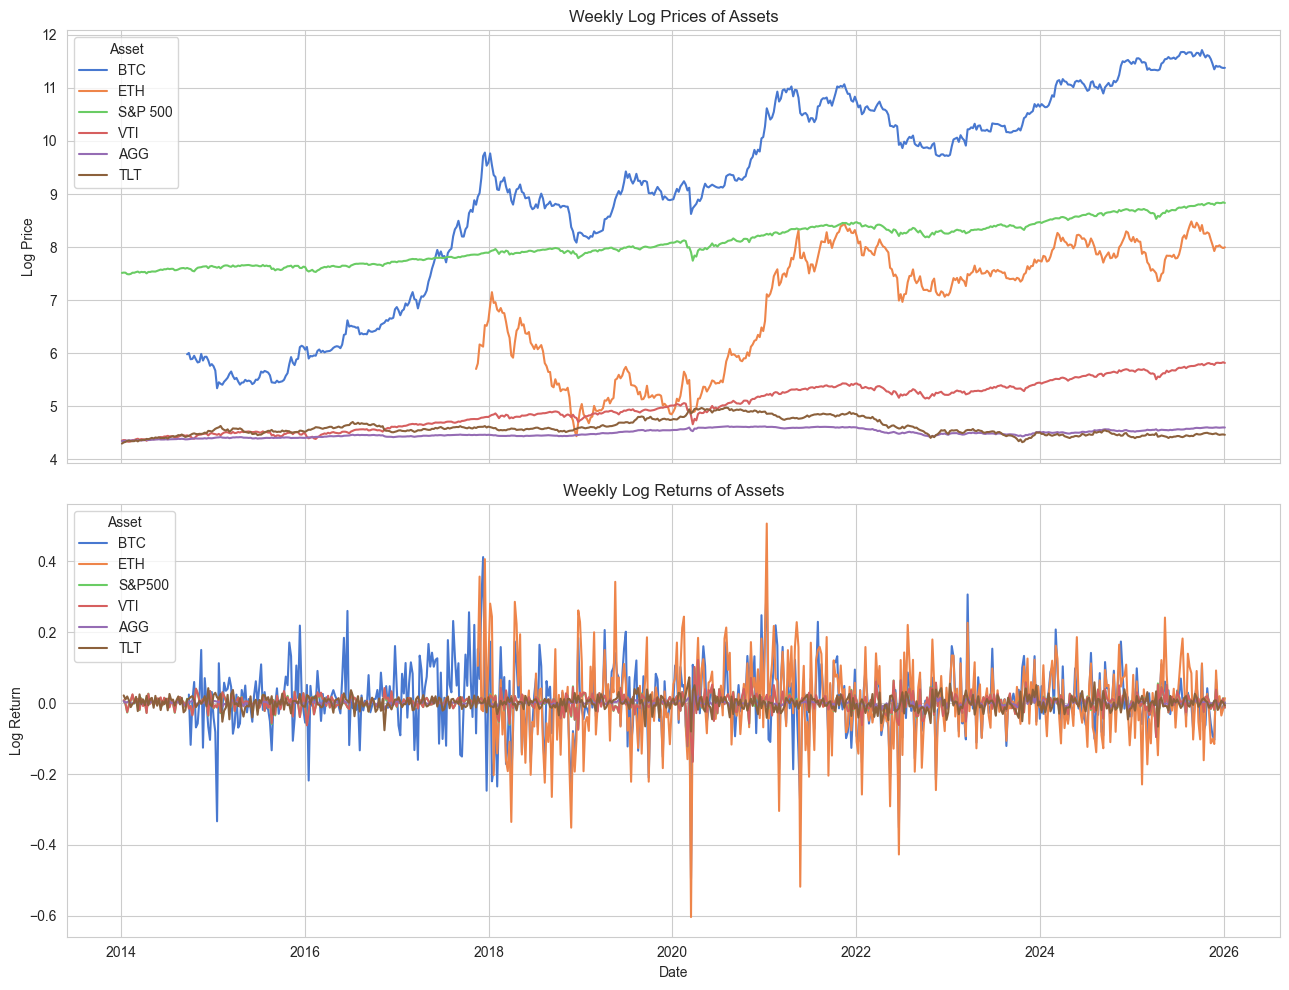

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

# normalized prices
sns.lineplot(
    data=log_weekly_prices_p,
    x='date',
    y='price',
    hue='asset',
    palette='muted',
    ax=axes[0]
)

axes[0].set_title("Weekly Log Prices of Assets")
axes[0].set_ylabel("Log Price")
axes[0].legend(title="Asset")

# log returns
sns.lineplot(
    data=log_weekly_returns_p,
    x='date',
    y='price',
    hue='asset',
    palette='muted',
    ax=axes[1]
)

axes[1].set_title("Weekly Log Returns of Assets")
axes[1].set_ylabel("Log Return")
axes[1].set_xlabel("Date")
axes[1].legend(title="Asset")

plt.tight_layout()
plt.savefig("../output/01_prices_returns.png", dpi=500, bbox_inches="tight")
plt.show()